# Análisis Exploratorio de Datos (EDA)

Este notebook realiza el análisis exploratorio de datos (EDA) del proyecto de predicción de demanda eléctrica en la Zona Metropolitana del Valle de México (ZMVM). El objetivo es caracterizar el comportamiento histórico de las variables disponibles, identificar patrones, anomalías y relaciones relevantes que guíen la construcción del modelo predictivo, para tener una primera propuesta de variables que se introducirán al modelo.

El análisis se organiza en cuatro secciones, cada una correspondiente a un conjunto de datos distinto:

1. **Factores Ambientales** — Variables meteorológicas horarias (2016–2024) para tres estaciones representativas de la ZMVM: Pachuca de Soto, Ciudad de México y Toluca de Lerdo. Fuente: Open-Meteo Historical Weather API.
2. **Indicadores Económicos** — Series mensuales del IGAE, IMAI e ITAEE (2016–2024) como proxies de la actividad económica nacional y estatal. Fuente: INEGI BISE vía INEGIpy.
3. **Demanda Real** — Registros horarios de demanda eléctrica estimada por balance energético para el área CEN (Gerencia Central — ZMVM), con cobertura de 2016 a 2024. Fuente: CENACE SIM.
4. **Precios Marginales Locales (PML)** — Precios horarios del Mercado de Día Anterior (MDA) para los 68 nodos de 230 kV de la ZMVM, agrupados en las zonas VDM Norte, VDM Sur y Centro Oriente. Fuente: API CENACE MEM.

### Carga de librerías

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Factores Ambientales

### Carga y estructura

In [86]:
RAW_DIR = Path('..')/ 'data' / 'raw'
pach_parq = RAW_DIR / 'clima_zmvm_combined.parquet'

df = pd.read_parquet(pach_parq)

In [87]:
location_map = {
    "cdmx_aeropuerto": "Ciudad de México, Ciudad de México, México",
    "pachuca":         "Pachuca de Soto, Hidalgo, México",
    "toluca":          "Toluca de Lerdo, Estado de México, México",
}

df["location"] = df["station_id"].map(location_map)

df.head()

,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover,apparent_temperature,dewpoint_2m,station_id,lat,lon,location
0,2016-04-01 00:00:00,14.0,54,0.0,6.2,0.0,4,11.9,4.9,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
1,2016-04-01 01:00:00,13.1,59,0.0,6.5,0.0,0,11.1,5.4,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
2,2016-04-01 02:00:00,12.3,62,0.0,6.9,0.0,0,10.1,5.1,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
3,2016-04-01 03:00:00,11.5,64,0.0,7.3,0.0,3,9.2,4.9,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"
4,2016-04-01 04:00:00,11.0,65,0.0,7.1,0.0,30,8.7,4.6,cdmx_aeropuerto,19.436,-99.0719,"Ciudad de México, Ciudad de México, México"


In [88]:
df.shape

(230184, 13)

In [89]:
tabla_info = pd.DataFrame({
    
    "DataType" : df.dtypes,
    "No Nulos" : df.notnull().sum(),
    "Nulos" : df.isnull().sum(),
    "Porcentaje Nulos" : df.isnull().mean() * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
datetime,datetime64[ns],230184,0,0.0
temperature_2m,float64,230184,0,0.0
relative_humidity_2m,int64,230184,0,0.0
precipitation,float64,230184,0,0.0
wind_speed_10m,float64,230184,0,0.0
shortwave_radiation,float64,230184,0,0.0
cloudcover,int64,230184,0,0.0
apparent_temperature,float64,230184,0,0.0
dewpoint_2m,float64,230184,0,0.0
station_id,object,230184,0,0.0


### Análisis por estación

Se presentan los valores promedio de las variables de interés expuestas en este dataset a través de los años para detectar consistencias, variaciones o patrones entre los mismos, del mismo se grafican la temperatura media diaria a través de los años en una serie temporal para cada ciudad.

#### Pachuca de Soto, Hidalgo

In [90]:
# --- Pachuca de Soto, Hidalgo ---
pachuca = df[df["location"] == "Pachuca de Soto, Hidalgo, México"].copy()

cols_interes = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "shortwave_radiation",
    "cloudcover",
]

pachuca.groupby(pachuca["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,14.8,14.3,79.3,0.1,7.2,233.7,68.3
2017,14.5,12.6,64.2,0.1,10.4,246.9,45.8
2018,14.5,12.7,67.5,0.1,10.3,242.1,51.5
2019,15.3,13.5,63.8,0.1,10.4,250.8,47.5
2020,15.2,13.3,63.0,0.0,10.7,255.2,45.4
2021,14.9,13.0,63.8,0.1,10.4,250.8,51.5
2022,14.9,12.9,63.6,0.1,10.6,260.7,51.4
2023,15.4,13.6,62.3,0.0,9.8,262.8,48.5
2024,15.9,14.2,60.5,0.1,9.0,259.8,52.6


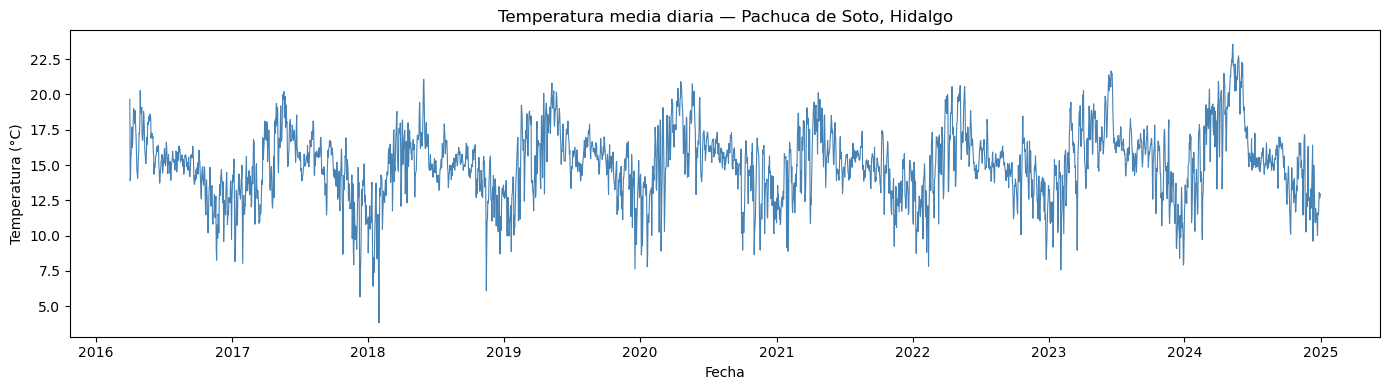

In [91]:
temp_diaria = pachuca.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="steelblue")
plt.title("Temperatura media diaria — Pachuca de Soto, Hidalgo")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

#### Ciudad de México

In [92]:
# --- Ciudad de México ---
cdmx = df[df["location"] == "Ciudad de México, Ciudad de México, México"].copy()

cdmx.groupby(cdmx["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,16.2,15.7,72.5,0.1,6.3,234.3,63.9
2017,16.8,15.3,58.9,0.1,8.1,246.0,48.1
2018,16.4,15.3,64.1,0.2,7.6,238.2,55.6
2019,17.3,16.1,60.2,0.1,7.7,247.9,50.8
2020,17.5,16.1,58.3,0.1,8.1,252.5,48.2
2021,16.8,15.6,60.1,0.2,7.6,250.1,53.9
2022,16.8,15.5,60.4,0.1,7.8,261.2,53.1
2023,17.3,16.0,59.1,0.1,7.7,262.0,50.4
2024,17.7,16.5,56.5,0.1,7.1,259.9,54.2


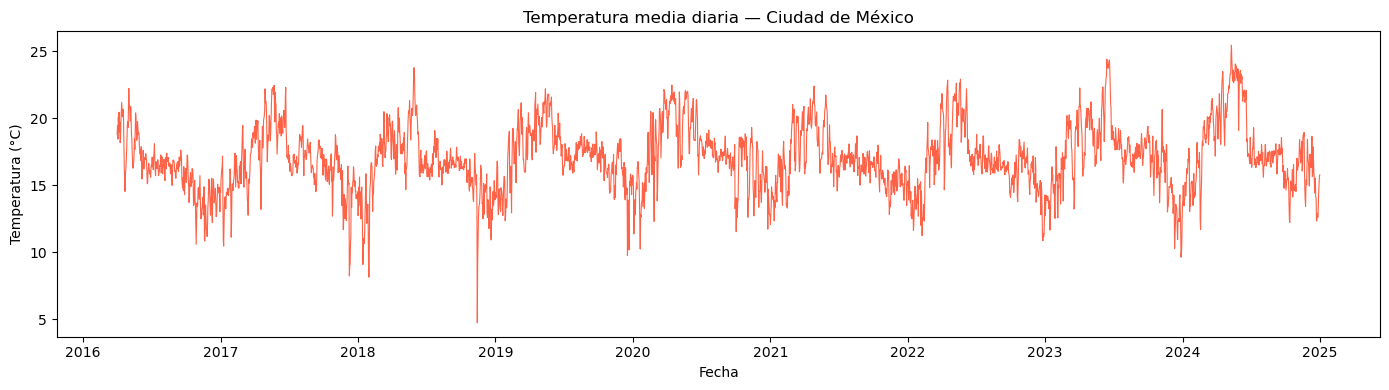

In [93]:
temp_diaria = cdmx.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="tomato")
plt.title("Temperatura media diaria — Ciudad de México")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

#### Toluca de Lerdo, Estado de México

In [94]:
# --- Toluca de Lerdo, Estado de México ---
toluca = df[df["location"] == "Toluca de Lerdo, Estado de México, México"].copy()

toluca.groupby(toluca["datetime"].dt.year)[cols_interes].mean().round(1)

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,cloudcover
datetime,,,,,,,
2016,13.7,12.8,75.4,0.2,5.3,231.3,67.5
2017,13.6,11.5,58.9,0.1,8.1,250.2,45.5
2018,13.2,11.4,64.5,0.1,7.9,236.5,54.6
2019,14.0,12.1,61.3,0.1,7.9,247.1,49.8
2020,13.9,12.0,61.0,0.1,8.1,252.7,46.5
2021,13.4,11.5,62.4,0.1,8.2,248.3,52.2
2022,13.2,11.3,63.4,0.1,7.8,257.3,52.4
2023,14.1,12.2,60.0,0.1,7.7,260.2,48.0
2024,14.5,12.6,56.1,0.1,7.2,256.3,51.5


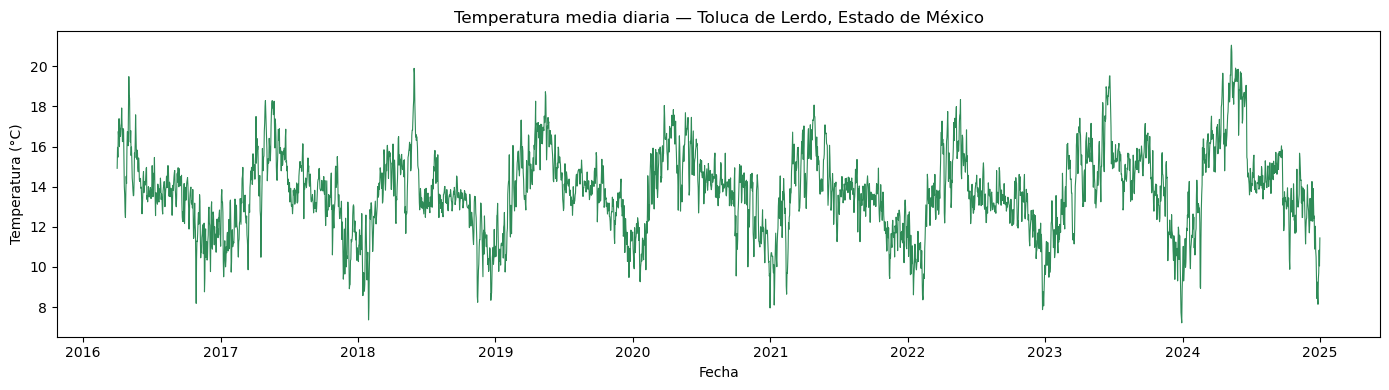

In [95]:
temp_diaria = toluca.resample("D", on="datetime")["temperature_2m"].mean()

plt.figure(figsize=(14, 4))
plt.plot(temp_diaria, linewidth=0.8, color="seagreen")
plt.title("Temperatura media diaria — Toluca de Lerdo, Estado de México")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

### Estacionalidad

#### Temperatura media mensual

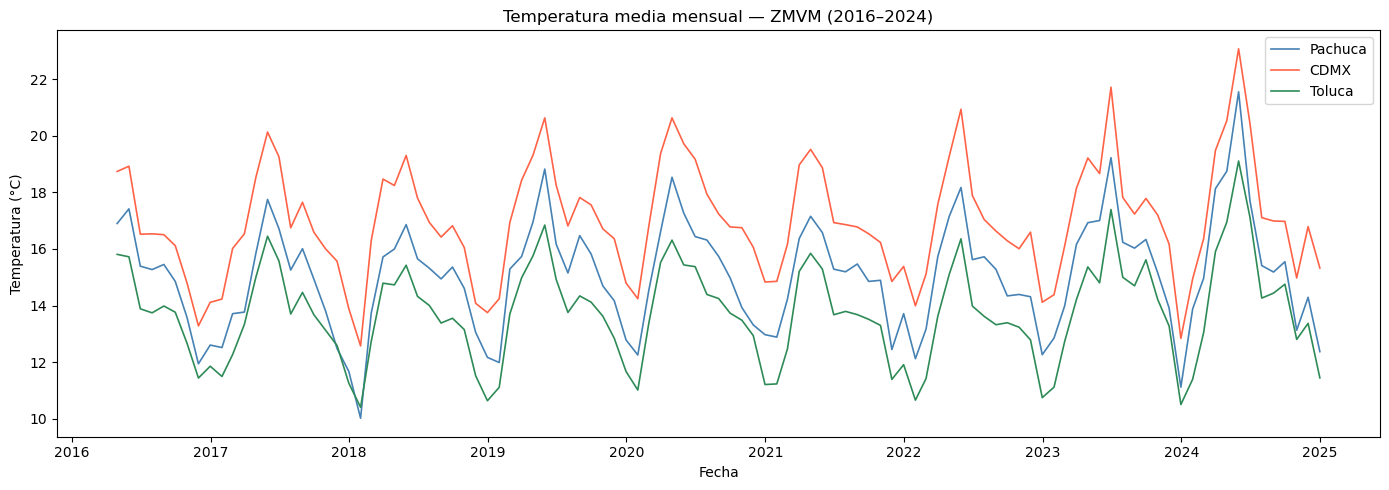

In [96]:
fig, ax = plt.subplots(figsize=(14, 5))

for ciudad, data, color in [
    ("Pachuca",  pachuca, "steelblue"),
    ("CDMX",     cdmx,    "tomato"),
    ("Toluca",   toluca,  "seagreen"),
]:
    temp_mensual = data.resample("M", on="datetime")["temperature_2m"].mean()
    ax.plot(temp_mensual, linewidth=1.2, label=ciudad, color=color)

ax.set_title("Temperatura media mensual — ZMVM (2016–2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.legend()
plt.tight_layout()
plt.show()

#### Distribución mensual (boxplot)

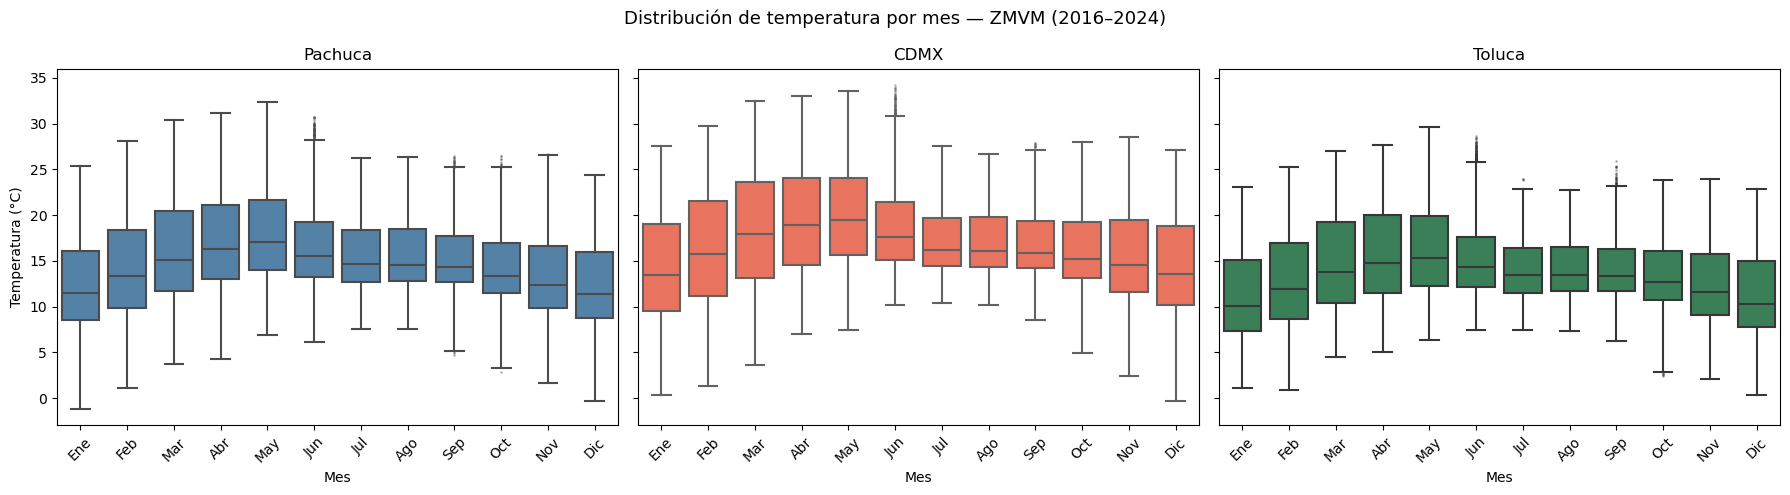

In [97]:
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (ciudad, data, color) in zip(axes, [
    ("Pachuca", pachuca, "steelblue"),
    ("CDMX",    cdmx,    "tomato"),
    ("Toluca",  toluca,  "seagreen"),
]):
    data_mes = data.copy()
    data_mes["mes"] = data_mes["datetime"].dt.month

    sns.boxplot(
        data=data_mes,
        x="mes",
        y="temperature_2m",
        ax=ax,
        color=color,
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    ax.set_title(ciudad)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Temperatura (°C)" if ax == axes[0] else "")
    ax.set_xticklabels(meses, rotation=45)

fig.suptitle("Distribución de temperatura por mes — ZMVM (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

#### Humedad Relativa Mensual

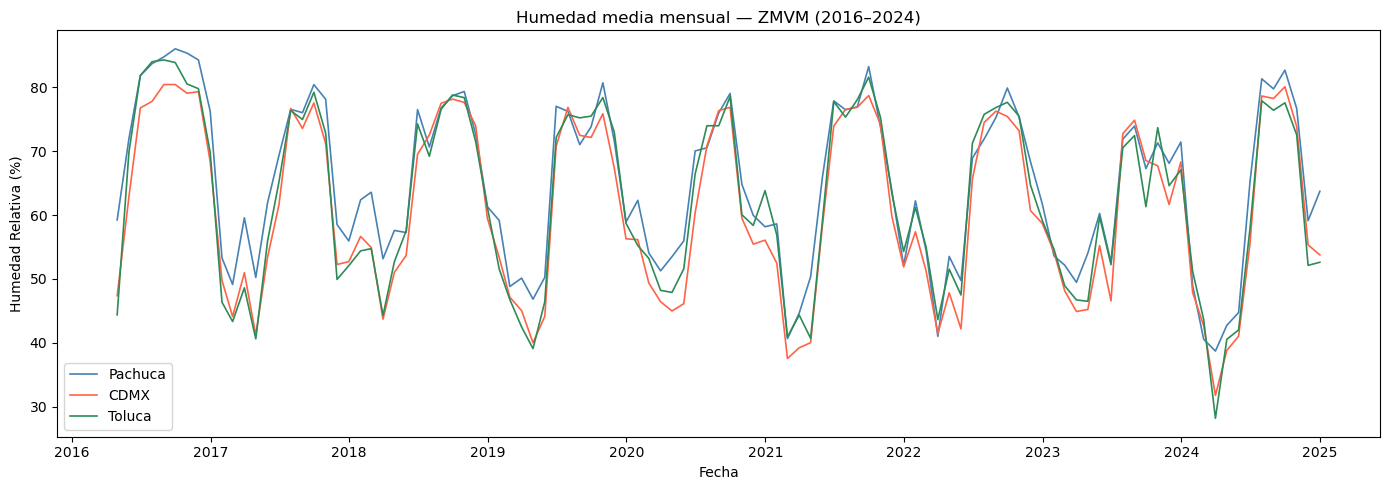

In [98]:
fig, ax = plt.subplots(figsize=(14, 5))

for ciudad, data, color in [
    ("Pachuca",  pachuca, "steelblue"),
    ("CDMX",     cdmx,    "tomato"),
    ("Toluca",   toluca,  "seagreen"),
]:
    humedity_mensual = data.resample("M", on="datetime")["relative_humidity_2m"].mean()
    ax.plot(humedity_mensual, linewidth=1.2, label=ciudad, color=color)

ax.set_title("Humedad media mensual — ZMVM (2016–2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Humedad Relativa (%)")
ax.legend()
plt.tight_layout()
plt.show()

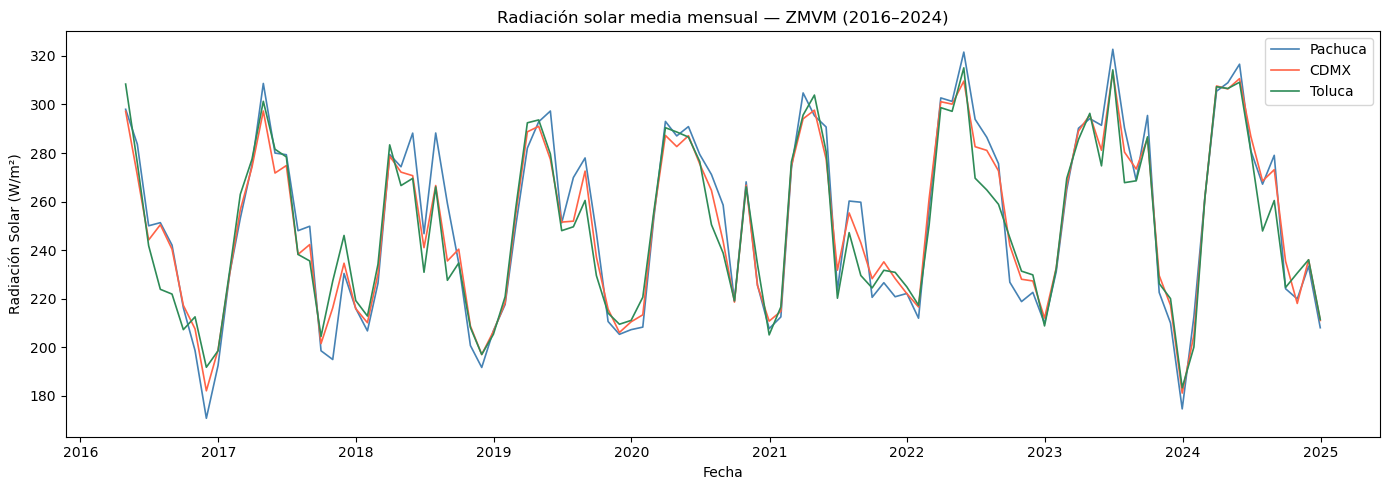

In [99]:
fig, ax = plt.subplots(figsize=(14, 5))

for ciudad, data, color in [
    ("Pachuca",  pachuca, "steelblue"),
    ("CDMX",     cdmx,    "tomato"),
    ("Toluca",   toluca,  "seagreen"),
]:
    rad_mensual = data.resample("M", on="datetime")["shortwave_radiation"].mean()
    ax.plot(rad_mensual, linewidth=1.2, label=ciudad, color=color)

ax.set_title("Radiación solar media mensual — ZMVM (2016–2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Radiación Solar (W/m²)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Indicadores Económicos

### Carga y estructura

In [100]:
ec_parq = RAW_DIR / 'economia_combined.parquet'

df_economia = pd.read_parquet(ec_parq)

df_economia.head().round(2)

,fecha,igae_total,imai_industrial,itaee_cdmx,itaee_hidalgo
0,2016-01-01,91.74,95.47,2957233.59,268833.62
1,2016-02-01,92.73,96.99,2957233.59,268833.62
2,2016-03-01,94.13,98.71,2957233.59,268833.62
3,2016-04-01,95.75,100.30,2957233.59,268833.62
4,2016-05-01,96.00,99.52,2957233.59,268833.62


In [101]:
df_economia.shape

(108, 5)

In [102]:
tabla_info = pd.DataFrame({
    
    "DataType" : df_economia.dtypes,
    "No Nulos" : df_economia.notnull().sum(),
    "Nulos" : df_economia.isnull().sum(),
    "Porcentaje Nulos" : df_economia.isnull().mean() * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
fecha,datetime64[ns],108,0,0.0
igae_total,float64,108,0,0.0
imai_industrial,float64,108,0,0.0
itaee_cdmx,float64,108,0,0.0
itaee_hidalgo,float64,108,0,0.0


### Estadísticas por año

In [103]:
cols_economia = ["igae_total", "imai_industrial", "itaee_cdmx", "itaee_hidalgo"]

tabla = (
    df_economia
    .groupby(df_economia["fecha"].dt.year)[cols_economia]
    .agg(["mean", "std"])
    .round(2)
)

tabla.columns = ["_".join(col) for col in tabla.columns]
tabla.index.name = "Año"
tabla

,igae_total_mean,igae_total_std,imai_industrial_mean,imai_industrial_std,itaee_cdmx_mean,itaee_cdmx_std,itaee_hidalgo_mean,itaee_hidalgo_std
Año,,,,,,,,
2016,96.17,2.63,99.21,1.79,2957233.59,0.0,268833.62,0.0
2017,98.02,2.93,99.83,2.71,3045539.86,0.0,270118.07,0.0
2018,100.00,2.42,100.00,2.63,3126459.57,0.0,276996.19,0.0
2019,99.56,1.88,98.26,2.62,3132839.08,0.0,272453.00,0.0
2020,91.57,7.91,89.57,9.72,2856971.79,0.0,244145.37,0.0
2021,96.73,3.01,95.29,2.70,2944607.21,0.0,251437.63,0.0
2022,100.10,3.44,99.82,2.91,2944607.21,0.0,251437.63,0.0
2023,103.19,3.01,102.78,3.34,2944607.21,0.0,251437.63,0.0
2024,104.53,2.28,102.17,2.73,2944607.21,0.0,251437.63,0.0


#### IGAE — Actividad económica global

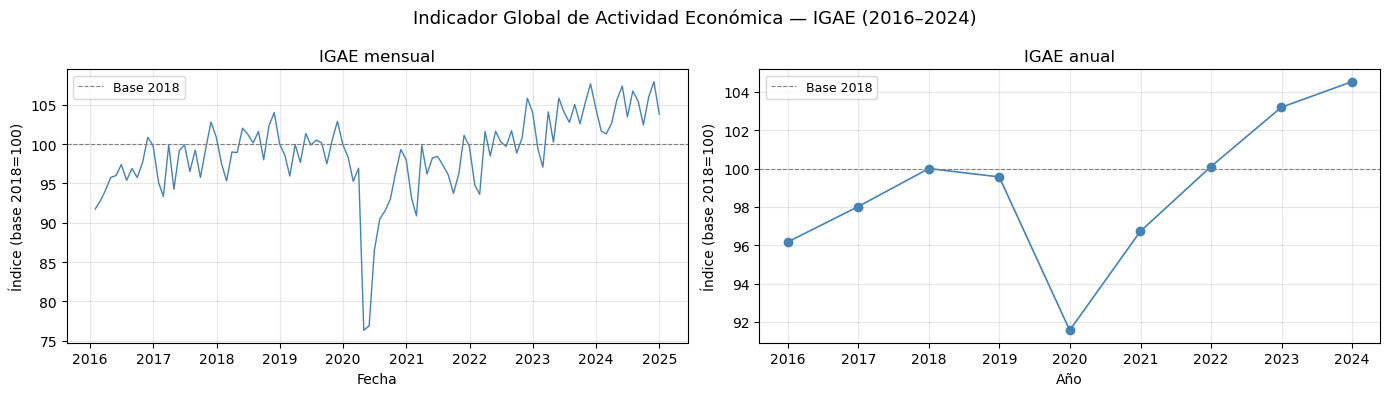

In [104]:
igae_mensual = df_economia.resample("M", on="fecha")["igae_total"].mean()
igae_anual = df_economia.resample("A", on="fecha", label="left")["igae_total"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(igae_mensual, linewidth=1.0, color="steelblue")
ax1.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax1.set_title("IGAE mensual")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Índice (base 2018=100)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(igae_anual, marker="o", linewidth=1.2, color="steelblue")
ax2.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax2.set_title("IGAE anual")
ax2.set_xlabel("Año")
ax2.set_ylabel("Índice (base 2018=100)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle("Indicador Global de Actividad Económica — IGAE (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

#### IMAI — Actividad industrial

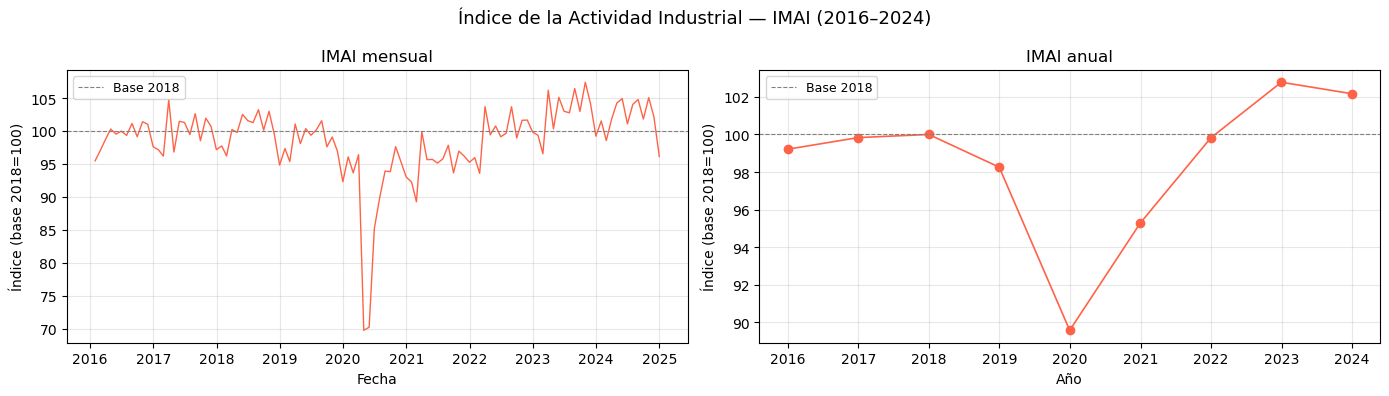

In [105]:
imai_mensual = df_economia.resample("M", on="fecha")["imai_industrial"].mean()
imai_anual   = df_economia.resample("A", on="fecha", label="left")["imai_industrial"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(imai_mensual, linewidth=1.0, color="tomato")
ax1.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax1.set_title("IMAI mensual")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Índice (base 2018=100)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(imai_anual, marker="o", linewidth=1.2, color="tomato")
ax2.axhline(100, color="gray", linewidth=0.8, linestyle="--", label="Base 2018")
ax2.set_title("IMAI anual")
ax2.set_xlabel("Año")
ax2.set_ylabel("Índice (base 2018=100)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle("Índice de la Actividad Industrial — IMAI (2016–2024)", fontsize=13)
plt.tight_layout()
plt.show()

#### ITAEE — Actividad económica por entidad

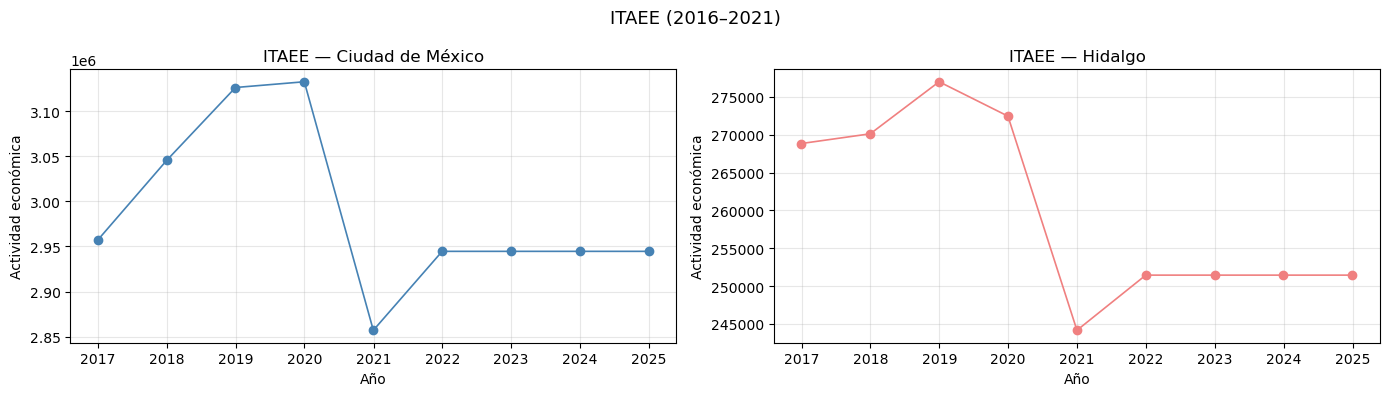

In [106]:
itaee_cdmx    = df_economia.resample("A", on="fecha")["itaee_cdmx"].mean()
itaee_hidalgo = df_economia.resample("A", on="fecha")["itaee_hidalgo"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(itaee_cdmx, marker="o", linewidth=1.2, color="steelblue")
ax1.set_title("ITAEE — Ciudad de México")
ax1.set_xlabel("Año")
ax1.set_ylabel("Actividad económica")
ax1.grid(alpha=0.3)

ax2.plot(itaee_hidalgo, marker="o", linewidth=1.2, color="lightcoral")
ax2.set_title("ITAEE — Hidalgo")
ax2.set_xlabel("Año")
ax2.set_ylabel("Actividad económica")
ax2.grid(alpha=0.3)

plt.suptitle("ITAEE (2016–2021)", fontsize=13)
plt.tight_layout()
plt.show()

El ITAEE muestra un crecimiento sostenido hasta 2019, seguido de una caída abrupta en 2021 como consecuencia de la pandemia COVID-19. Destaca que ambas economías no lograron recuperar los niveles pre-pandemia, estabilizándose en una meseta inferior. Esta contracción estructural es relevante para el modelo predictivo, ya que la actividad económica es un predictor de la demanda eléctrica — una economía que no se recupera sugiere una demanda que tampoco debería hacerlo completamente. Importante: los valores de 2022 en adelante son proyecciones por forward-fill del último dato publicado por INEGI (2021), ya que el ITAEE tiene un rezago de publicación de aproximadamente 3 años.

## 3. Demanda Real — Área CEN (ZMVM)

### Carga y estructura

In [107]:
dem_parq = RAW_DIR / 'demanda_real_combined.parquet'

df_demanda = pd.read_parquet(dem_parq)

df_demanda.head().round(2)

,sistema,area,hora,generacion_mwh,exportacion_total_mwh,demanda_balance_mwh,source_file,importacion_mwh,intercambio_mwh,fecha
0,BCA,BCA,1,1272.17,115.0,1157.17,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
1,BCS,BCS,1,191.33,0.0,191.33,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
2,SIN,CEN,1,4828.71,0.0,4828.71,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
3,SIN,NES,1,9737.85,0.0,9737.85,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01
4,SIN,NOR,1,2261.77,0.0,2261.77,Demanda Real Balance_1 Dia Operacion 2016-04-0...,NaN,None,2016-04-01


In [108]:
tabla_info = pd.DataFrame({
    
    "DataType" : df_demanda.dtypes,
    "No Nulos" : df_demanda.notnull().sum(),
    "Nulos" : df_demanda.isnull().sum().round(2),
    "Porcentaje Nulos" : df_demanda.isnull().mean().round(2) * 100   

})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
sistema,object,3151218,0,0.0
area,object,3151218,0,0.0
hora,int64,3151218,0,0.0
generacion_mwh,float64,3151218,0,0.0
exportacion_total_mwh,float64,2788984,362234,11.0
demanda_balance_mwh,float64,3151218,0,0.0
source_file,object,3151218,0,0.0
importacion_mwh,float64,1870552,1280666,41.0
intercambio_mwh,object,1870552,1280666,41.0
fecha,datetime64[ns],3151218,0,0.0


### Filtrado — Área CEN

In [109]:
# Filtrar solo área CEN (Gerencia Central = ZMVM)
df_cen = df_demanda[df_demanda["area"] == "CEN"][["fecha", "hora", "demanda_balance_mwh"]].copy()

# Resetear índice
df_cen = df_cen.sort_values(["fecha", "hora"]).reset_index(drop=True)

print(f"Registros totales:  {len(df_demanda):,}")
print(f"Registros CEN:      {len(df_cen):,}")
print(f"Rango:              {df_cen['fecha'].min().date()} → {df_cen['fecha'].max().date()}")
print(f"Columnas:           {list(df_cen.columns)}")
df_cen.head()

Registros totales:  3,151,218
Registros CEN:      350,135
Rango:              2016-04-01 → 2024-12-31
Columnas:           ['fecha', 'hora', 'demanda_balance_mwh']


,fecha,hora,demanda_balance_mwh
0,2016-04-01,1,4828.708
1,2016-04-01,1,4829.277
2,2016-04-01,1,4667.381
3,2016-04-01,2,4702.795
4,2016-04-01,2,4703.316


### Serie temporal

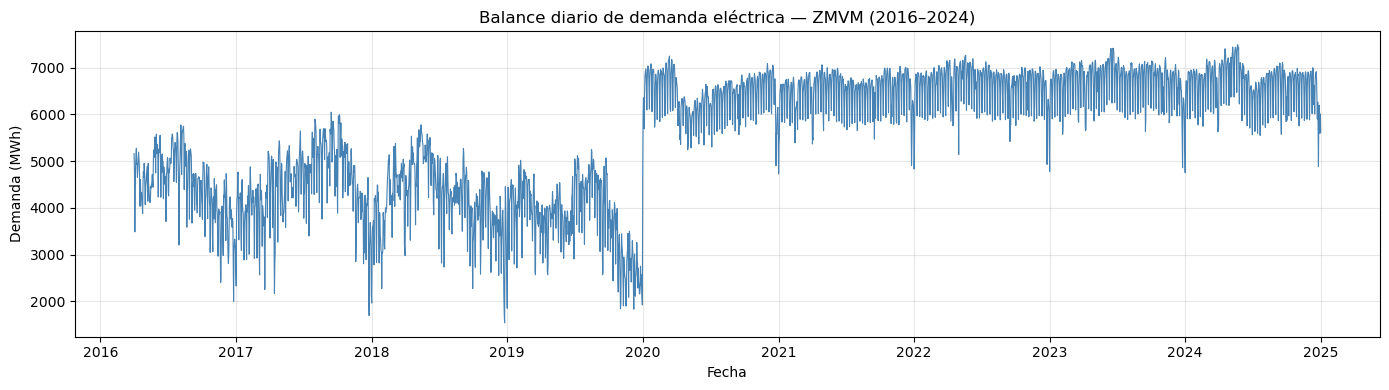

In [110]:
daily_demand = df_cen.resample("D", on="fecha")["demanda_balance_mwh"].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_demand, linewidth=0.8, color="steelblue")
plt.title("Balance diario de demanda eléctrica — ZMVM (2016–2024)")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

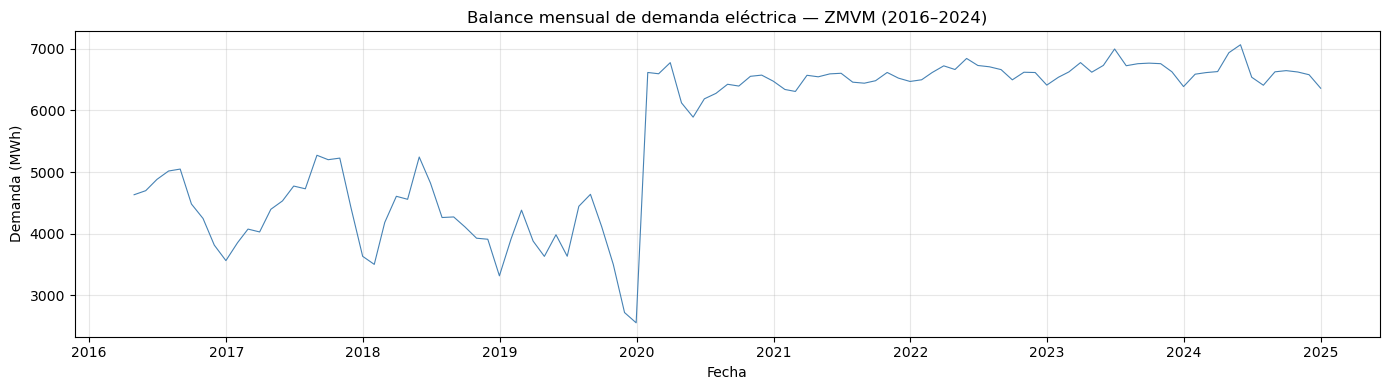

In [111]:
monthly_demand = df_cen.resample("M", on="fecha")["demanda_balance_mwh"].mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_demand, linewidth=0.8, color="steelblue")
plt.title("Balance mensual de demanda eléctrica — ZMVM (2016–2024)")
plt.xlabel("Fecha")
plt.ylabel("Demanda (MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análisis del quiebre estructural 2020

Las series temporales muestran un salto abrupto en la demanda del área CEN alrededor de 2020: el valor promedio horario prácticamente se duplica de un año al siguiente. Antes de asumir que este cambio refleja un crecimiento real del consumo, es necesario verificar si corresponde a una **reconfiguración administrativa de áreas de control por parte de CENACE**.

CENACE organiza el sistema eléctrico nacional en áreas de control (CEN, NES, OCC, ORI, etc.), y estas delimitaciones pueden modificarse cuando se reclasifican nodos o se reestructuran las zonas de despacho. Un cambio de este tipo incrementaría la demanda reportada para CEN sin que el consumo real dentro de su territorio histórico haya crecido.

Se realizan dos verificaciones para distinguir entre ambas hipótesis.

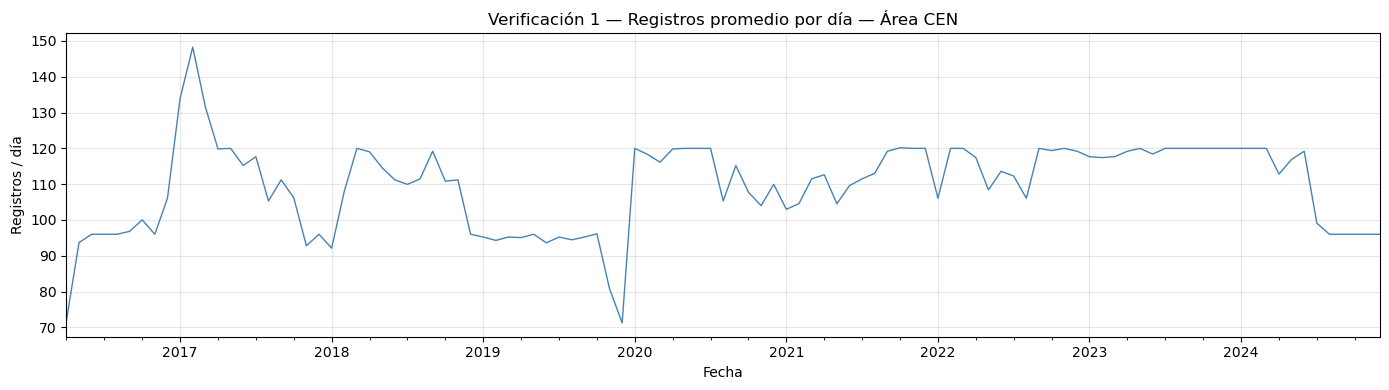

Promedio diario 2019: 91.9
Promedio diario 2020: 114.7


In [112]:
# Verificación 1 — Registros promedio por día
# Si el salto es real, los registros diarios deben mantenerse constantes.
# Si hubo una reclasificación (más nodos asignados a CEN), los registros aumentarán.
registros_dia = df_cen.groupby("fecha").size()

fig, ax = plt.subplots(figsize=(14, 4))
registros_dia.resample("M").mean().plot(ax=ax, color="steelblue", linewidth=1.0)
ax.set_title("Verificación 1 — Registros promedio por día — Área CEN")
ax.set_xlabel("Fecha")
ax.set_ylabel("Registros / día")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Promedio diario 2019: {registros_dia[registros_dia.index.year == 2019].mean():.1f}")
print(f"Promedio diario 2020: {registros_dia[registros_dia.index.year == 2020].mean():.1f}")

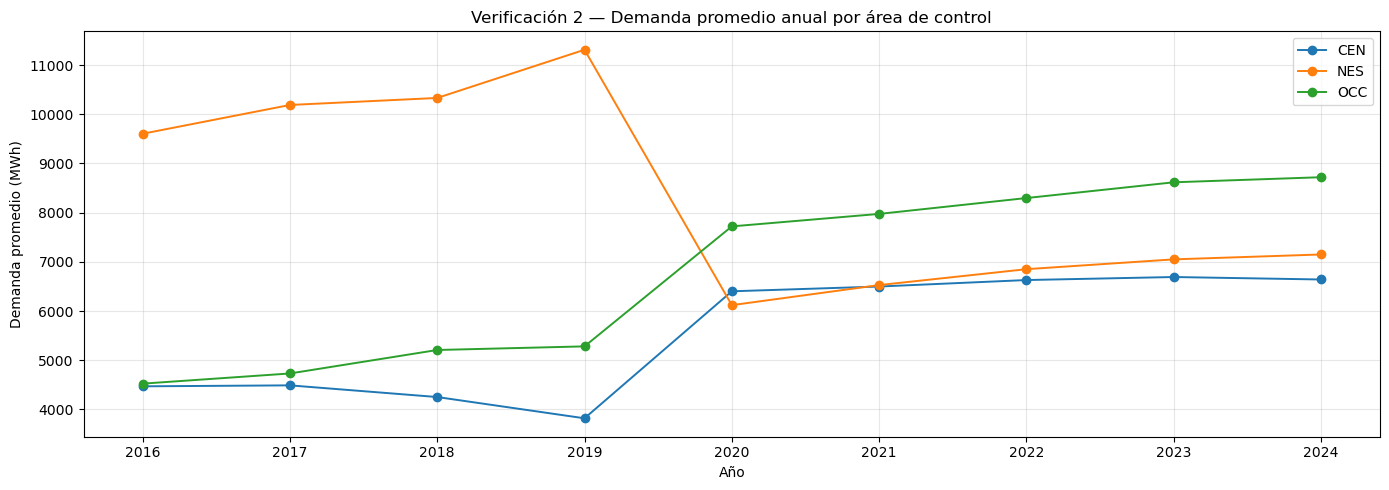

In [113]:
# Verificación 2 — Demanda promedio anual por área
# Si la reclasificación transfirió territorio de NES a CEN (y OCC),
# se debe observar: CEN sube, NES baja, OCC sube — en el mismo año.
areas_pivot = (
    df_demanda
    .groupby(["area", df_demanda["fecha"].dt.year])["demanda_balance_mwh"]
    .mean()
    .unstack("area")
)

areas_de_interes = [col for col in ["CEN", "NES", "OCC"] if col in areas_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
for area in areas_de_interes:
    ax.plot(areas_pivot.index, areas_pivot[area], marker="o", linewidth=1.4, label=area)

ax.set_title("Verificación 2 — Demanda promedio anual por área de control")
ax.set_xlabel("Año")
ax.set_ylabel("Demanda promedio (MWh)")
ax.set_xticks(areas_pivot.index)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Hallazgos del quiebre estructural

Los resultados de las dos verificaciones son consistentes con una **reconfiguración administrativa de áreas de control** ocurrida alrededor de enero–febrero de 2020, no con un crecimiento real de la demanda:

- **Verificación 1 — Registros por día:** El número de registros diarios en el área CEN aumentó aproximadamente un 26 % entre 2019 y 2020. Si el salto fuera puramente demanda real, los registros por día deberían mantenerse constantes (el mismo número de horas reportadas). Un incremento en los registros indica que más fuentes de datos (nodos, sub-áreas o sistemas) comenzaron a reportar bajo el código CEN a partir de 2020.

- **Verificación 2 — Balance entre áreas:** En el año 2020, la demanda promedio de CEN sube en la misma magnitud en que baja NES, mientras OCC también registra un incremento menor. Este movimiento espejo entre áreas es la firma característica de una reclasificación territorial: CENACE reasignó nodos o sub-sistemas que antes reportaban como NES (y parcialmente OCC) al área CEN, posiblemente como parte de la reestructuración operativa derivada de la reforma energética.

**Implicación metodológica:** El salto en la demanda de CEN no es totalmente comparable antes y después de 2020. Para el modelo predictivo, se segmentará el análisis en dos periodos: **2016–2019** (área CEN original) y **2020–2024** (área CEN ampliada). Los patrones relativos — estacionalidad, perfiles horarios y correlaciones con variables climáticas — se mantienen válidos en ambos periodos.

### Perfiles de consumo

#### Perfil horario

El dataset incluye 31 registros con hora = 25, lo cual no es coherente con el sistema de 24 horas. Estos registros se omiten en el análisis.

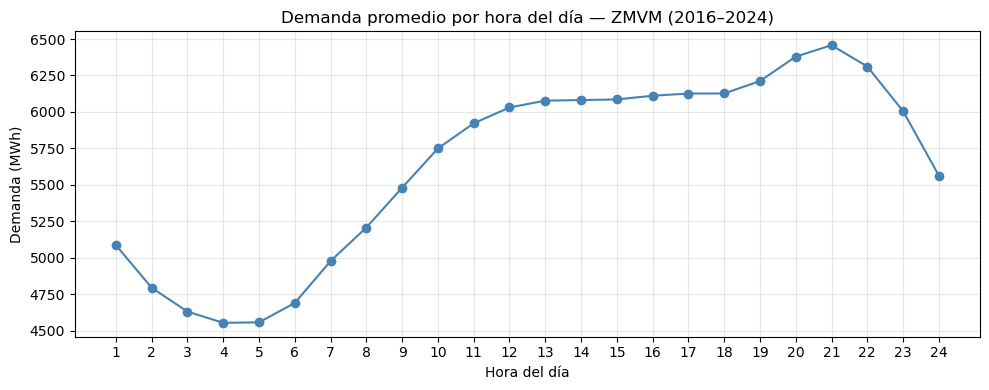

In [114]:
df_cen = df_cen[df_cen["hora"] <= 24]
hour = df_cen.groupby("hora")["demanda_balance_mwh"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hour.index, hour.values, marker="o", color="steelblue")
plt.title("Demanda promedio por hora del día — ZMVM (2016–2024)")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (MWh)")
plt.xticks(range(1, 25))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Comparativo Pre vs Post COVID

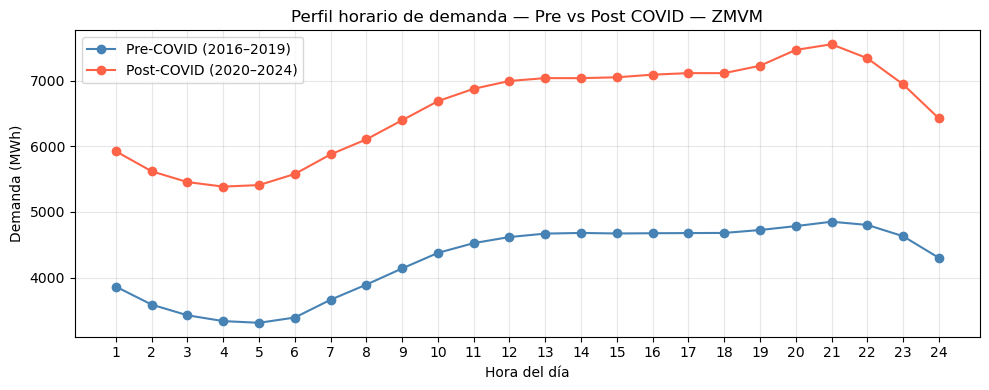

In [115]:
df_cen = df_demanda[df_demanda["area"] == "CEN"][["fecha", "hora", "demanda_balance_mwh"]].copy()
df_cen = df_cen.sort_values(["fecha", "hora"]).reset_index(drop=True)
df_cen = df_cen[df_cen["hora"] <= 24]

pre_covid  = df_cen[df_cen["fecha"].dt.year < 2020]
post_covid = df_cen[df_cen["fecha"].dt.year >= 2020]

hour_pre  = pre_covid.groupby("hora")["demanda_balance_mwh"].mean()
hour_post = post_covid.groupby("hora")["demanda_balance_mwh"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hour_pre.index,  hour_pre.values,  marker="o", color="steelblue", label="Pre-COVID (2016–2019)")
plt.plot(hour_post.index, hour_post.values, marker="o", color="tomato",    label="Post-COVID (2020–2024)")
plt.title("Perfil horario de demanda — Pre vs Post COVID — ZMVM")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (MWh)")
plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Perfil semanal

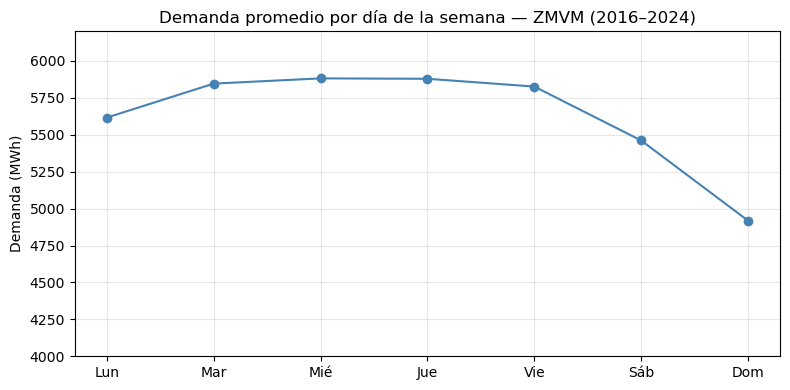

In [116]:
df_cen["dia_sem"] = df_cen["fecha"].dt.dayofweek

weekly = df_cen.groupby("dia_sem")["demanda_balance_mwh"].mean()

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

plt.figure(figsize=(8, 4))
plt.plot(weekly.index, weekly.values, marker="o", color="steelblue")
plt.xticks(range(7), dias)
plt.ylim(4000, 6200)
plt.title("Demanda promedio por día de la semana — ZMVM (2016–2024)")
plt.ylabel("Demanda (MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Heatmap — Demanda por hora y mes

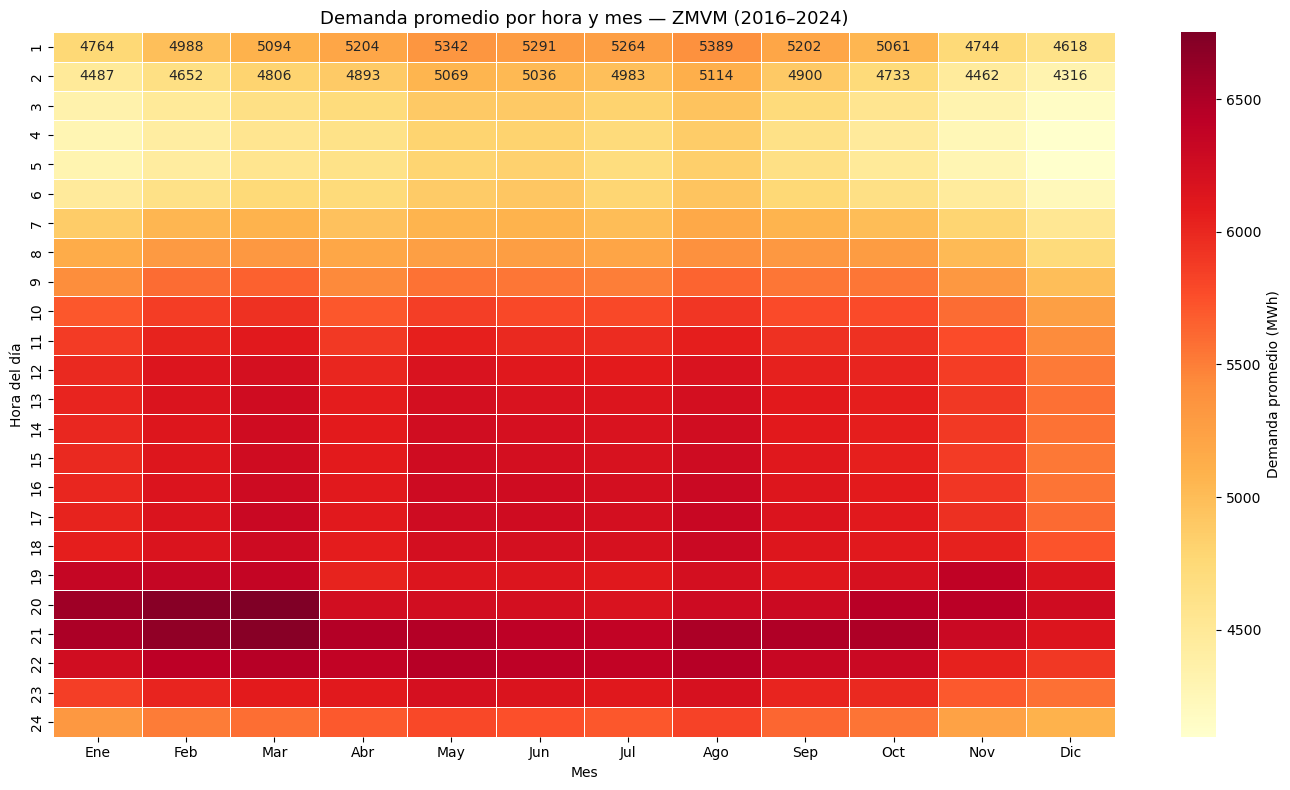

In [117]:
meses_label = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

pivot = (
    df_cen.assign(mes=df_cen["fecha"].dt.month)
    .groupby(["hora", "mes"])["demanda_balance_mwh"]
    .mean()
    .unstack(level="mes")
)
pivot.columns = meses_label

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Demanda promedio (MWh)"},
)
ax.set_title("Demanda promedio por hora y mes — ZMVM (2016–2024)", fontsize=13)
ax.set_xlabel("Mes")
ax.set_ylabel("Hora del día")
plt.tight_layout()
plt.show()

## 4. Precios Marginales Locales (PML)

### Carga y estructura

In [118]:
RAW_DIR = Path('..')/ 'data' / 'raw'
pach_parq = RAW_DIR / 'pml_zmvm_MDA_2016-01-01_2024-12-31.parquet'

df_pml = pd.read_parquet(pach_parq)

df_pml.head()

,nodo,nombre,mercado,hora,fecha,pml,pml_ene,pml_per,pml_cng
0,01ACO-230,Acolman,MDA,1,2016-01-29,774.66,773.97,0.65,0.04
1,01ACO-230,Acolman,MDA,10,2016-01-29,826.11,829.8,-3.72,0.04
2,01ACO-230,Acolman,MDA,11,2016-01-29,859.94,867.6,-7.42,-0.24
3,01ACO-230,Acolman,MDA,12,2016-01-29,838.92,842.49,-3.35,-0.22
4,01ACO-230,Acolman,MDA,13,2016-01-29,885.67,891.54,-5.78,-0.1


In [119]:
tabla_info = pd.DataFrame({
    "DataType" : df_pml.dtypes,
    "No Nulos" : df_pml.notnull().sum(),
    "Nulos" : df_pml.isnull().sum(),
    "Porcentaje Nulos" : df_pml.isnull().mean() * 100   
})

tabla_info

,DataType,No Nulos,Nulos,Porcentaje Nulos
nodo,object,4977557,0,0.0
nombre,object,4977557,0,0.0
mercado,object,4977557,0,0.0
hora,object,4977557,0,0.0
fecha,datetime64[ns],4977557,0,0.0
pml,object,4977557,0,0.0
pml_ene,object,4977557,0,0.0
pml_per,object,4977557,0,0.0
pml_cng,object,4977557,0,0.0


### Clasificación por zonas CENACE

In [120]:
# Mapeo nodo → zona CENACE
ZONA_NODO = {
    # VDM Norte
    "01ACO-230": "N", "01ACS-230": "N", "01AFM-230": "N", "01ATI-230": "N",
    "01AZC-230": "N", "01CCZ-230": "N", "01CPM-230": "N", "01CRG-230": "N",
    "01CTG-230": "N", "01DVA-230": "N", "01ECA-230": "N", "01ECR-230": "N",
    "01IRO-230": "N", "01JLC-230": "N", "01JRB-230": "N", "01LAR-230": "N",
    "01LDG-230": "N", "01LFG-230": "N", "01LVE-230": "N", "01MAD-230": "N",
    "01OTM-230": "N", "01RAT-230": "N", "01REM-230": "N", "01TCC-230": "N",
    "01TCM-230": "N", "01TIZ-230": "N", "01TKM-230": "N", "01TTH-230": "N",
    "01TUL-230": "N", "01VAE-230": "N", "01VAJ-230": "N", "01VIC-230": "N",
    "01XAL-230": "N",
    # VDM Sur
    "01AGU-230": "S", "01ATE-230": "S", "01AYO-230": "S", "01CJM-230": "S",
    "01COA-230": "S", "01CRS-230": "S", "01CUL-230": "S", "01IXL-230": "S",
    "01OLI-230": "S", "01SNG-230": "S", "01TAX-230": "S", "01TDK-230": "S",
    "01TEH-230": "S", "01TIA-230": "S", "01TOP-230": "S", "01TTC-230": "S",
    "01TTU-230": "S", "01XOC-230": "S",
    # Centro Oriente (Corredor CDMX–Pachuca)
    "01ATK-230": "C", "01BBV-230": "C", "01CEI-230": "C", "01CFI-230": "C",
    "01CRU-230": "C", "01EST-230": "C", "01EVD-230": "C", "01IZT-230": "C",
    "01MLP-230": "C", "01MOR-230": "C", "01OCE-230": "C", "01ODB-230": "C",
    "01PYG-230": "C", "01ROL-230": "C", "01RSL-230": "C", "01SOX-230": "C",
    "01ZAM-230": "C",
}

ZONA_NOMBRE = {"N": "VDM Norte", "S": "VDM Sur", "C": "Centro Oriente"}
ZONA_COLOR  = {"N": "steelblue", "S": "tomato", "C": "seagreen"}

# Agregar columna zona
df_pml["zona"] = df_pml["nodo"].map(ZONA_NODO)
df_pml["zona_nombre"] = df_pml["zona"].map(ZONA_NOMBRE)

# Convertir columnas numéricas
for col in ["pml", "pml_ene", "pml_per", "pml_cng"]:
    df_pml[col] = pd.to_numeric(df_pml[col], errors="coerce")

# Hora también a int
df_pml["hora"] = pd.to_numeric(df_pml["hora"], errors="coerce")

print("Nodos sin zona asignada:", df_pml[df_pml["zona"].isna()]["nodo"].unique())
print("\nDistribución de nodos por zona:")
print(df_pml.groupby("zona_nombre")["nodo"].nunique().rename("nodos"))


Nodos sin zona asignada: []

Distribución de nodos por zona:
zona_nombre
Centro Oriente    17
VDM Norte         33
VDM Sur           18
Name: nodos, dtype: int64


### Estadísticas por zona

In [121]:
tabla_zona = (
    df_pml.groupby("zona_nombre")["pml"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
tabla_zona.columns = ["Registros", "Media", "Std", "Min", "Mediana", "Max"]
tabla_zona.index.name = "Zona"
tabla_zona


,Registros,Media,Std,Min,Mediana,Max
Zona,,,,,,
Centro Oriente,1255921,1072.44,723.57,-182.12,896.82,26792.27
VDM Norte,2432499,1064.62,720.16,-182.38,890.71,26858.54
VDM Sur,1289137,1090.07,740.38,0.00,909.59,26911.12


### Distribución por zona (boxplot)

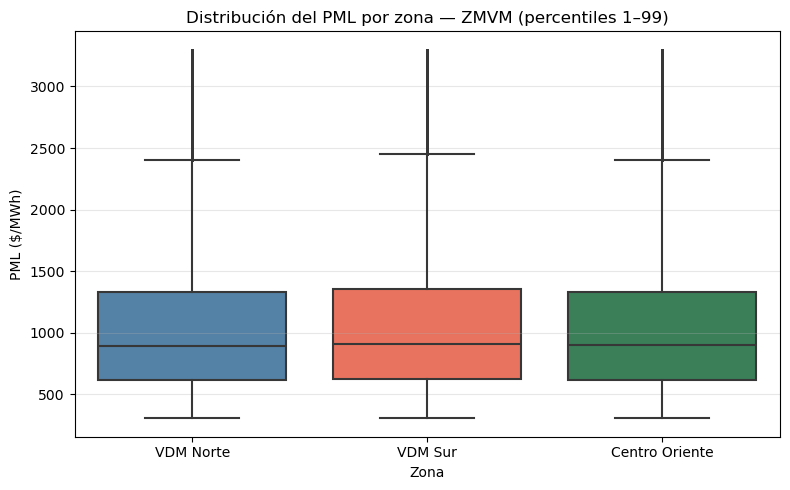

In [122]:
p1  = df_pml["pml"].quantile(0.01)
p99 = df_pml["pml"].quantile(0.99)
df_box = df_pml[(df_pml["pml"] >= p1) & (df_pml["pml"] <= p99)].copy()

palette_nombre = {v: ZONA_COLOR[k] for k, v in ZONA_NOMBRE.items()}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_box,
    x="zona_nombre",
    y="pml",
    palette=palette_nombre,
    order=["VDM Norte", "VDM Sur", "Centro Oriente"],
    flierprops=dict(marker=".", markersize=2, alpha=0.2),
    ax=ax,
)
ax.set_title("Distribución del PML por zona — ZMVM (percentiles 1–99)")
ax.set_xlabel("Zona")
ax.set_ylabel("PML ($/MWh)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Evolución temporal

#### Evolución mensual

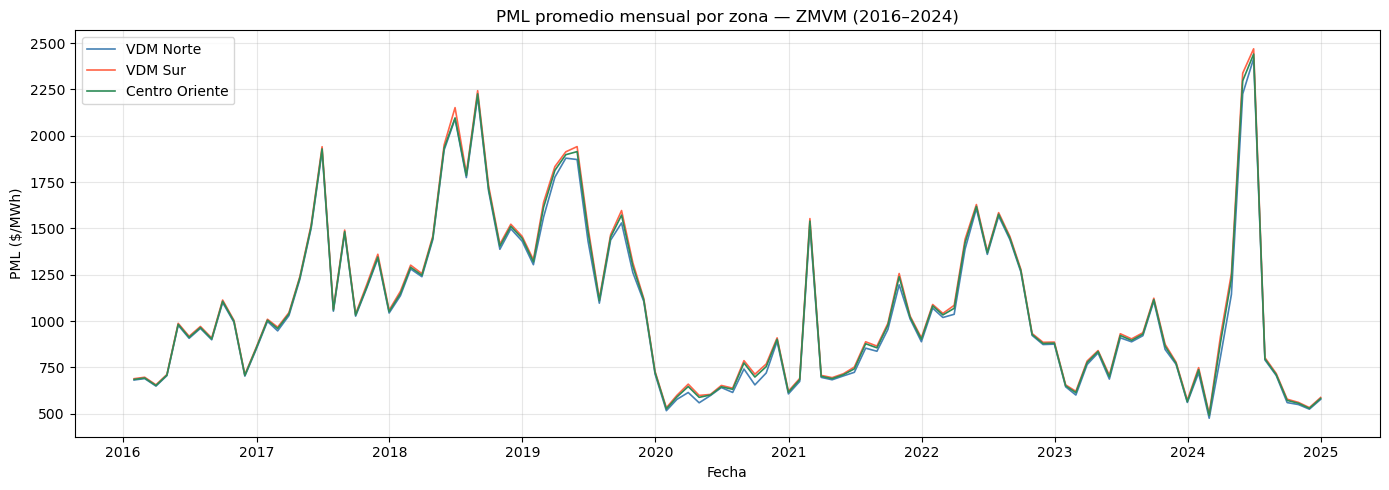

In [123]:
fig, ax = plt.subplots(figsize=(14, 5))

for zona_id, zona_label in ZONA_NOMBRE.items():
    serie = (
        df_pml[df_pml["zona"] == zona_id]
        .resample("M", on="fecha")["pml"]
        .mean()
    )
    ax.plot(serie, linewidth=1.2, label=zona_label, color=ZONA_COLOR[zona_id])

ax.set_title("PML promedio mensual por zona — ZMVM (2016–2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("PML ($/MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Tendencia anual

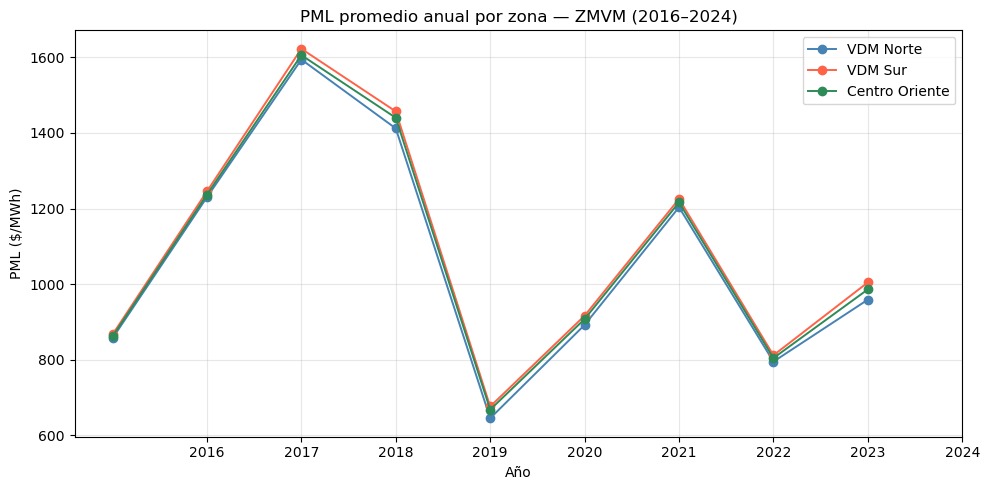

In [124]:
fig, ax = plt.subplots(figsize=(10, 5))

for zona_id, zona_label in ZONA_NOMBRE.items():
    anual = (
        df_pml[df_pml["zona"] == zona_id]
        .resample("A", on="fecha", label="left")["pml"]
        .mean()
    )
    ax.plot(anual.index.year, anual.values, marker="o", linewidth=1.4,
            label=zona_label, color=ZONA_COLOR[zona_id])

ax.set_title("PML promedio anual por zona — ZMVM (2016–2024)")
ax.set_xlabel("Año")
ax.set_ylabel("PML ($/MWh)")
ax.set_xticks(range(2016, 2025))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

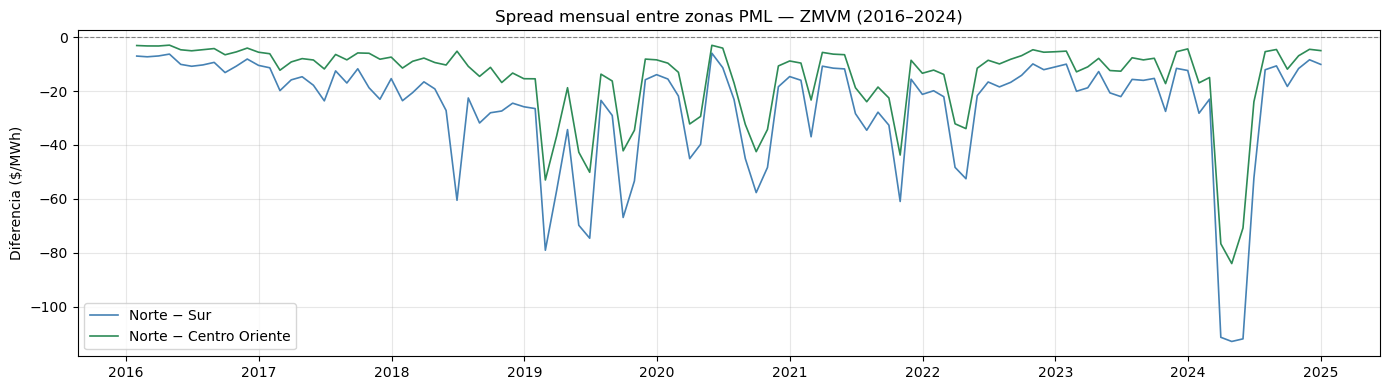

In [125]:
# Spread mensual entre zonas
pml_norte  = df_pml[df_pml["zona"]=="N"].resample("M", on="fecha")["pml"].mean()
pml_sur    = df_pml[df_pml["zona"]=="S"].resample("M", on="fecha")["pml"].mean()
pml_centro = df_pml[df_pml["zona"]=="C"].resample("M", on="fecha")["pml"].mean()

spread_ns = pml_norte - pml_sur
spread_nc = pml_norte - pml_centro

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spread_ns,  linewidth=1.2, label="Norte − Sur",            color="steelblue")
ax.plot(spread_nc,  linewidth=1.2, label="Norte − Centro Oriente", color="seagreen")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Spread mensual entre zonas PML — ZMVM (2016–2024)")
ax.set_ylabel("Diferencia ($/MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Spread entre zonas

El spread mensual entre zonas revela cuatro hallazgos clave:

1. **El spread es consistentemente negativo** — VDM Norte es sistemáticamente más barato que VDM Sur y Centro Oriente. Esto refleja la mayor disponibilidad de generación en el norte de la ZMVM (plantas de ciclo combinado en Tula e Hidalgo), que reduce el precio local.

2. **Los picos de spread indican congestión** — cuando las líneas de transmisión norte–sur no tienen capacidad suficiente para transferir energía barata del norte, las zonas sur y centro deben abastecerse con generación local más costosa, ampliando la diferencia de precios.

3. **Periodos críticos identificados:**
   - **2018–2019**: spread Norte–Sur alcanza −80 $/MWh, el más intenso del periodo analizado hasta entonces.
   - **Febrero 2021**: spike puntual hacia cero, posiblemente relacionado con el apagón de Texas que interrumpió el suministro de gas natural hacia México.
   - **2024**: el peor evento de toda la serie con −120 $/MWh, coincidiendo con la crisis energética nacional por sequía (afectación a hidroeléctricas) y problemas de suministro de gas.

4. **El corredor CDMX–Pachuca muestra menor congestión** — Norte − Centro Oriente (verde) se mantiene consistentemente por encima de Norte − Sur, lo que indica que el corredor hacia Pachuca tiene mayor capacidad de transmisión disponible que el eje norte–sur. Este resultado es relevante para la hipótesis central del proyecto sobre el corredor CDMX–Pachuca.

### Perfil horario por zona

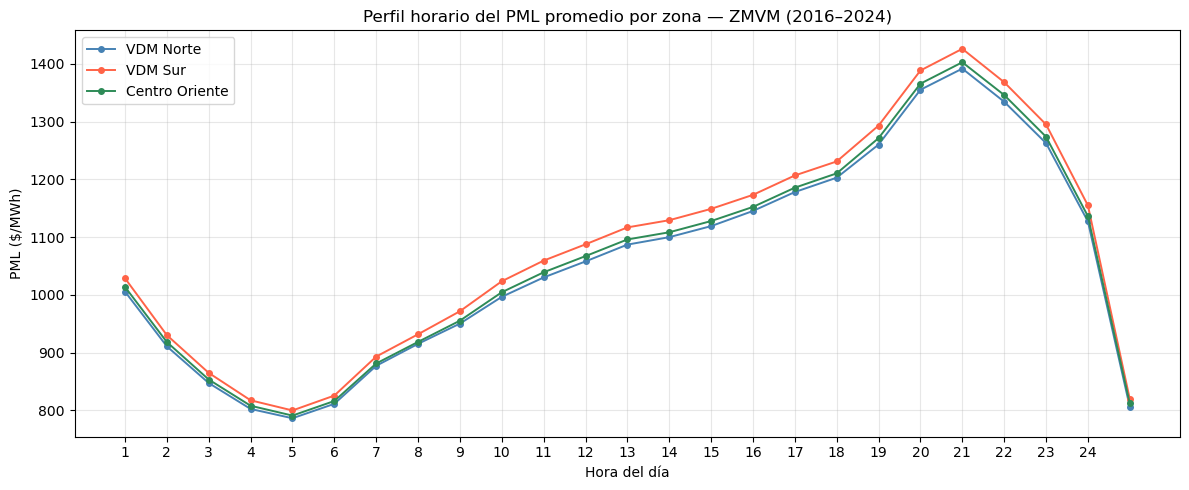

In [126]:
fig, ax = plt.subplots(figsize=(12, 5))

for zona_id, zona_label in ZONA_NOMBRE.items():
    perfil = (
        df_pml[df_pml["zona"] == zona_id]
        .groupby("hora")["pml"]
        .mean()
    )
    ax.plot(perfil.index, perfil.values, marker="o", markersize=4,
            linewidth=1.4, label=zona_label, color=ZONA_COLOR[zona_id])

ax.set_title("Perfil horario del PML promedio por zona — ZMVM (2016–2024)")
ax.set_xlabel("Hora del día")
ax.set_ylabel("PML ($/MWh)")
ax.set_xticks(range(1, 25))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
